# 1.不同网络不同方法下的Kendall数据对比表

In [3]:
import pandas as pd

# 读取数据
kendall_df = pd.read_excel("kendall_analysis-1.xlsx").iloc[:,:-1]

# 获取数值列（假设第一列为网络名称）
value_cols = kendall_df.columns[1:]

# 识别最后一行的网络名称（判断是否为 "Std."）
last_row_name = kendall_df.iloc[-2, 0]  # 最后一行的第一列值

def highlight_best(row):
    # 判断是否为 Std. 行
    if row.name == kendall_df.index[-2] and last_row_name == "Std.":
        target_val = row[value_cols].min()   # 高亮最小值
    else:
        target_val = row[value_cols].max()   # 高亮最大值
    
    styles = [''] * len(row)
    for col in value_cols:
        if row[col] == target_val:
            idx = row.index.get_loc(col)
            styles[idx] = 'color: red; font-weight: bold'
    return styles

styled_df = kendall_df.style.apply(highlight_best, axis=1)
styled_df

,Network,degree_centrality,betweenness_centrality,closeness_centrality,eigenvector_centrality,k_core,KIGM,WCC,TEW,WKSD,HyCRA(CombSUM),HyCRA(MC1),HyCRA(BordaCount)
0,Dolphin,0.792658,0.547276,0.659051,0.710370,0.732264,0.832489,0.819069,0.792832,0.828798,0.831675,0.786349,0.832425
1,Jazz,0.841655,0.474553,0.723453,0.900454,0.811003,0.887297,0.876139,0.817444,0.898488,0.866356,0.802359,0.866239
2,Disease,0.599863,0.285271,0.507884,0.588626,0.583780,0.770112,0.697169,0.687424,0.711740,0.765144,0.766393,0.765100
3,Email,0.801007,0.639378,0.819638,0.889662,0.823283,0.874699,0.854020,0.829023,0.865538,0.871298,0.832071,0.871337
4,Netscience,0.618623,0.393251,0.342634,0.422725,0.567491,0.752502,0.655439,0.678052,0.731518,0.702816,0.722228,0.702871
5,Wikivote,0.622599,0.665545,0.823595,0.808655,0.795362,0.865048,0.847280,0.809040,0.830589,0.849555,0.794360,0.838244
6,Yeast,0.528479,0.485373,0.706317,0.634457,0.548555,0.770406,0.750594,0.683348,0.766835,0.788479,0.764766,0.788500
7,Power,0.489162,0.341323,0.383162,0.625709,0.443176,0.634860,0.541433,0.526513,0.597850,0.636640,0.645890,0.636646
8,911,0.786600,0.503501,0.733237,0.831074,0.771853,0.874072,0.841445,0.808278,0.877890,0.865681,0.824499,0.865381
9,CA-CSphd,0.382230,0.385369,0.567456,0.615851,0.246219,0.736659,0.624967,0.649858,0.747852,0.671001,0.697482,0.671024


# 2. 绘制柱形组图对不同网络下不同方法kendall结果进行值大小的比较

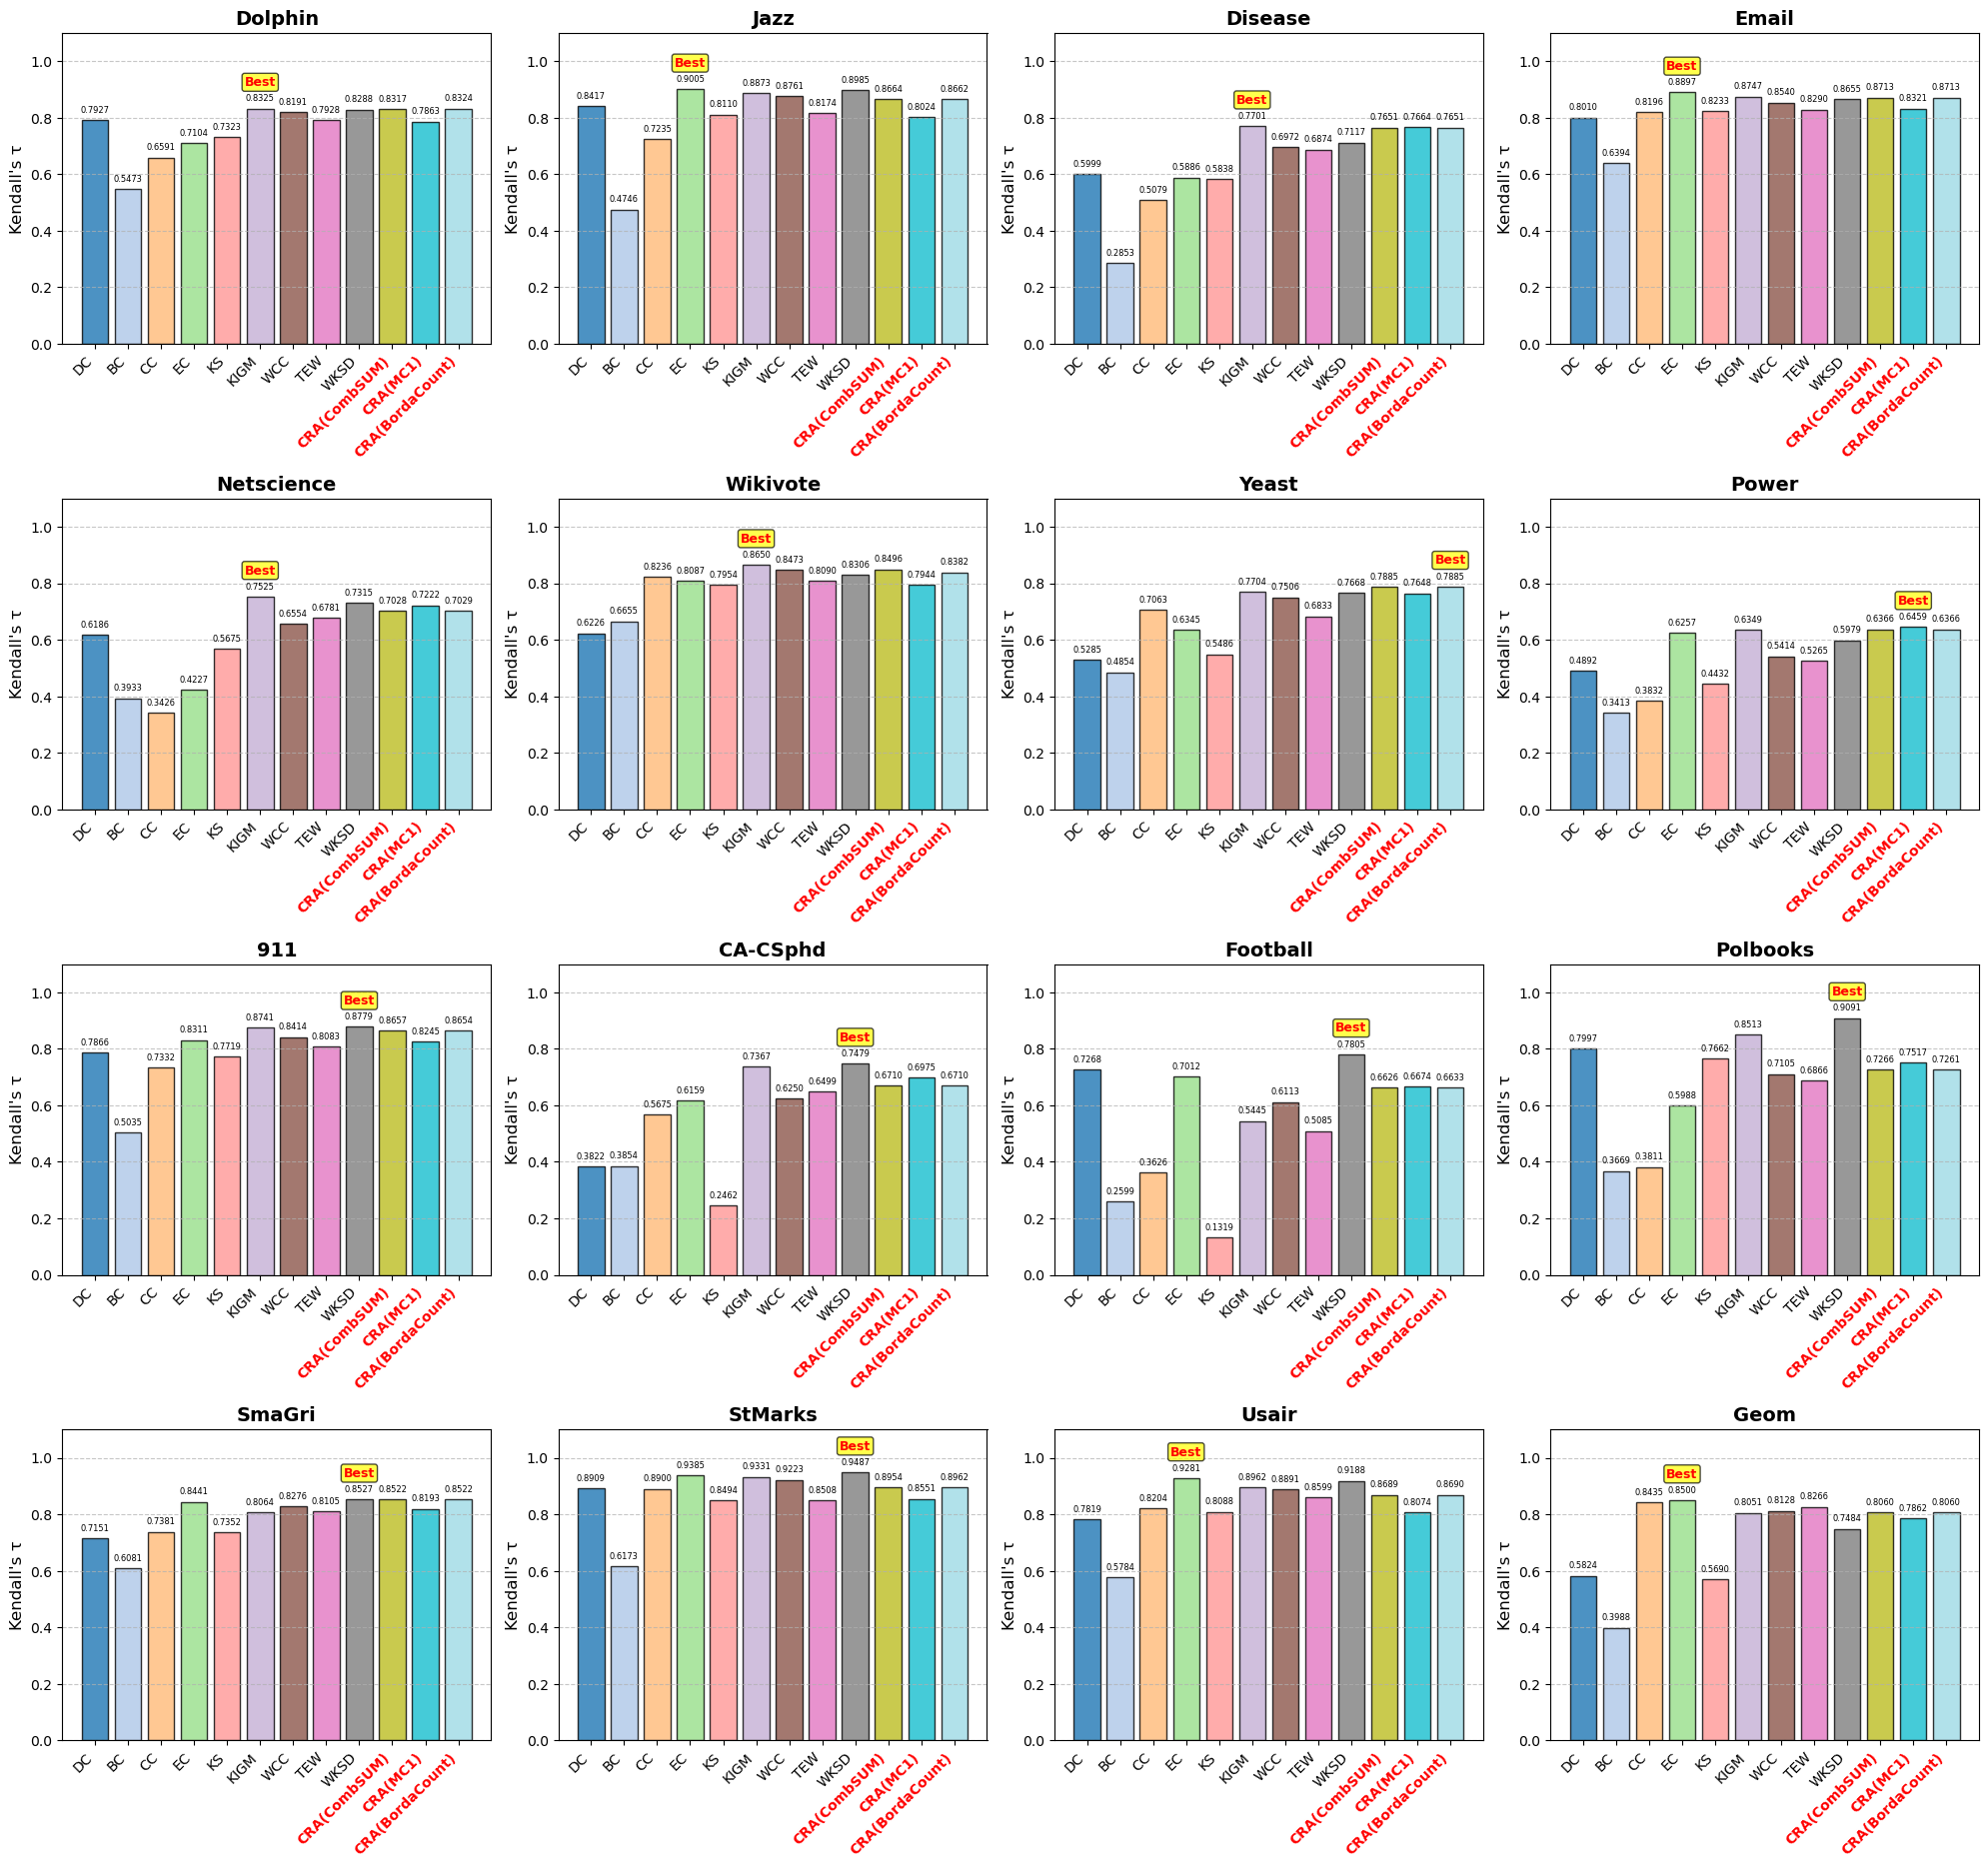

图表已保存为:Kendall_Comparison_Across_Networks.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取数据
file_path = "kendall_analysis-1.xlsx"
df = pd.read_excel(file_path, sheet_name="kendall")

# 排除汇总行
df_networks = df[~df["Network"].isin(["Mean", "Std."])].copy()

# 获取方法列（排除 Network 和 最后一列）
all_method_cols = [col for col in df_networks.columns if col != "Network"]
method_cols = all_method_cols[:-1]

# 定义高亮方法及其新标签
highlight_methods = ['CombSUM', 'MC1', 'BordaCount']
highlight_labels = ['CRA(CombSUM)', 'CRA(MC1)', 'CRA(BordaCount)']
# 高亮方法的高饱和颜色
highlight_colors = {'CombSUM': '#e41a1c', 'MC1': '#377eb8', 'BordaCount': '#4daf4a'}

# 为每个方法分配颜色
def get_color(method, idx):
    if method in highlight_methods:
        return highlight_colors[method]
    else:
        # 其他方法使用 tab20 调色板
        colors = plt.cm.tab20(np.linspace(0, 1, len(method_cols)))
        return colors[idx]

# 创建子图
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()

for ax, (idx, row) in zip(axes, df_networks.iterrows()):
    network = row["Network"]
    values = row[method_cols].values

    # 生成颜色列表
    bar_colors = [get_color(m, i) for i, m in enumerate(method_cols)]

    bars = ax.bar(method_cols, values, color=bar_colors, edgecolor='black', alpha=0.8)

    ax.set_title(f"{network}", fontsize=14, fontweight='bold')
    ax.set_ylabel("Kendall's τ", fontsize=12)
    ax.set_ylim(0, 1.10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # 设置 x 轴标签：替换高亮方法的标签，并设置红色加粗
    xtick_labels = []
    for m in method_cols:
        if m in highlight_methods:
            idx_hl = highlight_methods.index(m)
            xtick_labels.append(highlight_labels[idx_hl])
        else:
            xtick_labels.append(m)
    ax.set_xticks(range(len(method_cols)))
    ax.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=10)
    # 单独设置高亮方法标签的样式
    for tick_label in ax.get_xticklabels():
        if tick_label.get_text() in highlight_labels:
            tick_label.set_color('red')
            tick_label.set_fontweight('bold')

    # 柱顶数值（四位小数）
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.4f}", ha='center', va='bottom', fontsize=6)

    # 标注最优柱子
    max_val = max(values)
    max_idx = values.argmax()
    best_bar = bars[max_idx]
    ax.text(best_bar.get_x() + best_bar.get_width()/2,
            best_bar.get_height() + 0.07,
            "Best", ha='center', va='bottom', fontsize=9, fontweight='bold',
            color='red', bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.7))

# 生成图例（包含高亮方法的新名称和其他方法的示例）
from matplotlib.patches import Patch
legend_elements = []
for m, label in zip(highlight_methods, highlight_labels):
    legend_elements.append(Patch(facecolor=highlight_colors[m], edgecolor='black', label=label))
# 其他方法的代表（取第一个非高亮方法）
other_methods = [m for m in method_cols if m not in highlight_methods]
if other_methods:
    # 获取第一个其他方法的颜色作为示例
    first_other = other_methods[0]
    idx_other = method_cols.index(first_other)
    other_color = get_color(first_other, idx_other)
    legend_elements.append(Patch(facecolor=other_color, edgecolor='black', label='Other Methods (tab20)'))
#fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.02),
#           ncol=len(highlight_methods)+1, fontsize=10, frameon=True)

# 添加总标题
#fig.suptitle("Kendall's τ Comparison Across Networks", fontsize=16, fontweight='bold')

# 调整布局
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.subplots_adjust(top=0.92)
plt.savefig("Kendall_Comparison_Across_Networks.png", dpi=600, bbox_inches='tight')
plt.show()
print(f"图表已保存为:Kendall_Comparison_Across_Networks.png")

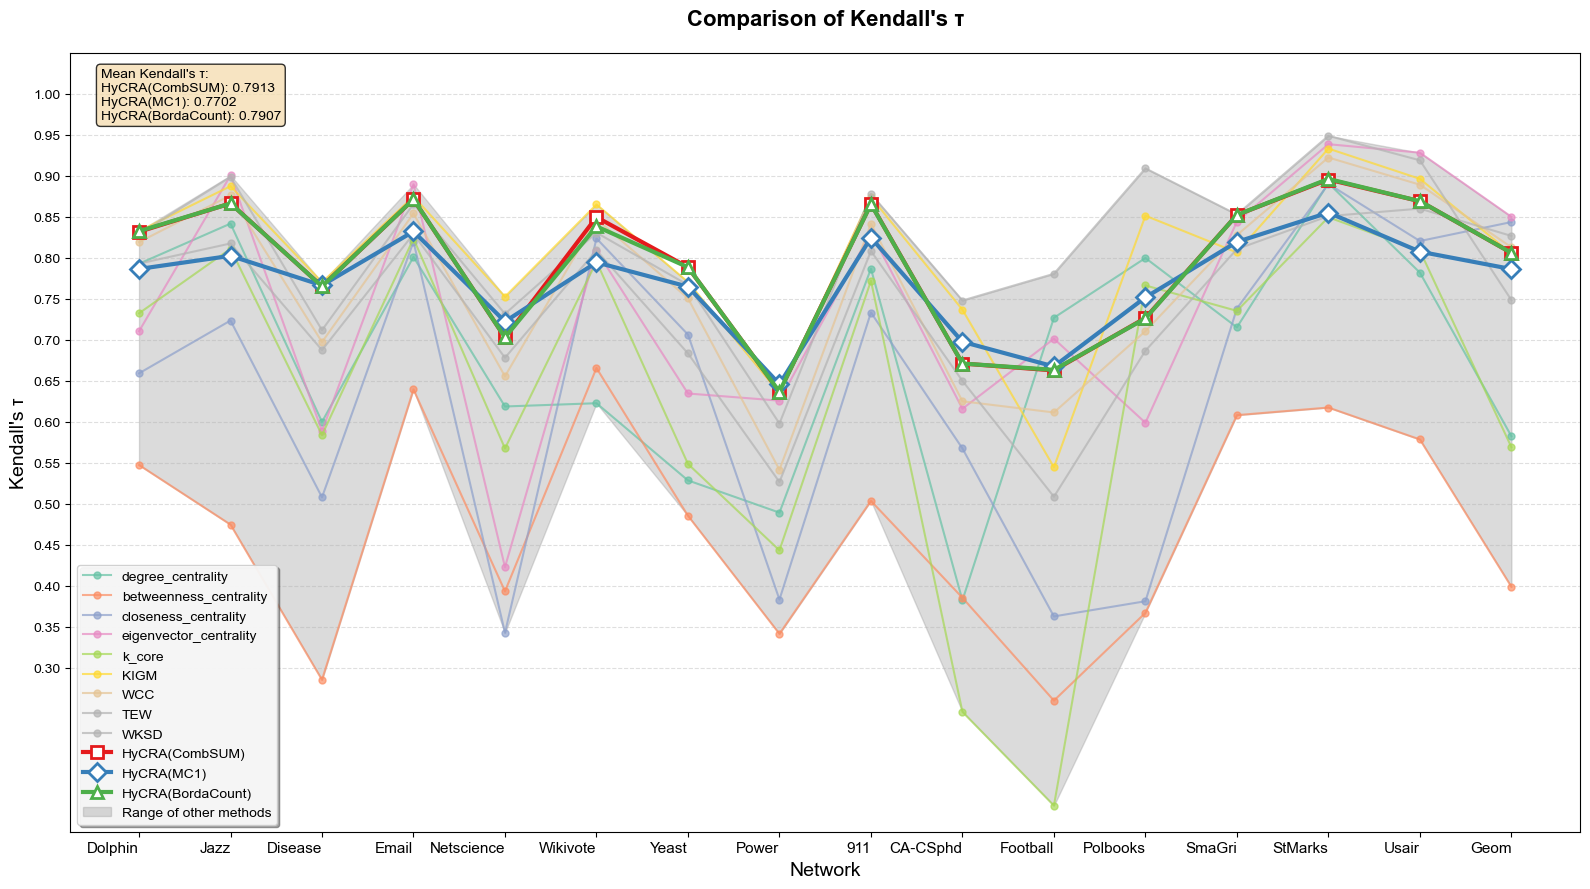

图表已保存为:kendall_highlight.png


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 设置字体（英文不需要中文字体，但若系统有英文默认即可）
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据
df = pd.read_excel('kendall_analysis-1.xlsx', sheet_name='kendall')

# 提取网络和方法
networks = df['Network'].iloc[:-3].tolist()
all_methods = ['degree_centrality', 'betweenness_centrality', 'closeness_centrality', 
               'eigenvector_centrality', 'k_core', 'KIGM', 'WCC', 
               'TEW', 'WKSD', 'HyCRA(CombSUM)', 'HyCRA(MC1)', 'HyCRA(BordaCount)']
				

# 高亮的方法
highlight_methods = ['HyCRA(CombSUM)', 'HyCRA(MC1)', 'HyCRA(BordaCount)']
other_methods = [m for m in all_methods if m not in highlight_methods]

# 提取数据
data_all = df[all_methods].iloc[:-3].values

# 高亮方法的颜色和标记形状
highlight_colors = {
    'HyCRA(CombSUM)': '#e41a1c',      # red
    'HyCRA(MC1)': '#377eb8',          # blue
    'HyCRA(BordaCount)': '#4daf4a'    # green
}
highlight_markers = {
    'HyCRA(CombSUM)': 's',      # square
    'HyCRA(MC1)': 'D',          # diamond
    'HyCRA(BordaCount)': '^'    # triangle up
}

# 其他方法使用 Set2 调色板（美观且区分度高）
other_colors = plt.cm.Set2(np.linspace(0, 1, len(other_methods)))

# 线条样式
highlight_linewidth = 3
other_linewidth = 1.5

# 创建图形
fig, ax = plt.subplots(figsize=(16, 9), dpi=100)

# 1. 绘制其他方法（使用不同颜色）
for i, method in enumerate(other_methods):
    ax.plot(networks, data_all[:, all_methods.index(method)], 
            color=other_colors[i], linewidth=other_linewidth, 
            marker='o', markersize=5, alpha=0.7, label=method)

# 2. 绘制高亮方法（使用不同形状）
for method in highlight_methods:
    idx = all_methods.index(method)
    ax.plot(networks, data_all[:, idx], 
            color=highlight_colors[method], linewidth=highlight_linewidth,
            marker=highlight_markers[method], markersize=9, markerfacecolor='white', 
            markeredgewidth=2, markeredgecolor=highlight_colors[method],
            label=method, zorder=10)

# 3. 计算并绘制其他方法的取值范围阴影（使用浅蓝色 '#a6cee3' ，透明度0.2）
other_values = np.array([data_all[:, all_methods.index(m)] for m in other_methods])
min_other = np.min(other_values, axis=0)
max_other = np.max(other_values, axis=0)
ax.fill_between(range(len(networks)), min_other, max_other, 
                color='#999999', alpha=0.35, label='Range of other methods')

# 设置图表（英文标签）
ax.set_xlabel('Network', fontsize=14,)
ax.set_ylabel("Kendall's τ", fontsize=14)
ax.set_title('Comparison of Kendall\'s τ', fontsize=16, fontweight='bold', pad=20)

ax.set_xticks(range(len(networks)))
ax.set_xticklabels(networks, ha='right', fontsize=11)
ax.set_ylim(0.1, 1.05)
ax.set_yticks(np.arange(0.3, 1.05, 0.05))
ax.grid(True, linestyle='--', alpha=0.4, axis='y')

# 图例（放在右下角）
legend = ax.legend(loc='lower left', fontsize=10, frameon=True, fancybox=True, shadow=True)
legend.get_frame().set_alpha(0.9)

# 可选：添加平均Kendall系数文本标注（英文）
mean_comb = np.mean(data_all[:, all_methods.index('HyCRA(CombSUM)')])
mean_mc1 = np.mean(data_all[:, all_methods.index('HyCRA(MC1)')])
mean_borda = np.mean(data_all[:, all_methods.index('HyCRA(BordaCount)')])
ax.text(0.02, 0.98, f'Mean Kendall\'s τ:\nHyCRA(CombSUM): {mean_comb:.4f}\nHyCRA(MC1): {mean_mc1:.4f}\nHyCRA(BordaCount): {mean_borda:.4f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('kendall_highlight.png', dpi=600, bbox_inches='tight')
plt.show()
print(f"图表已保存为:kendall_highlight.png")

# 3、不同方法在不同网络下的分布情况和 稳定性分析， 分布函数（左边小提琴）和 稳定性分析（右边盒须图）

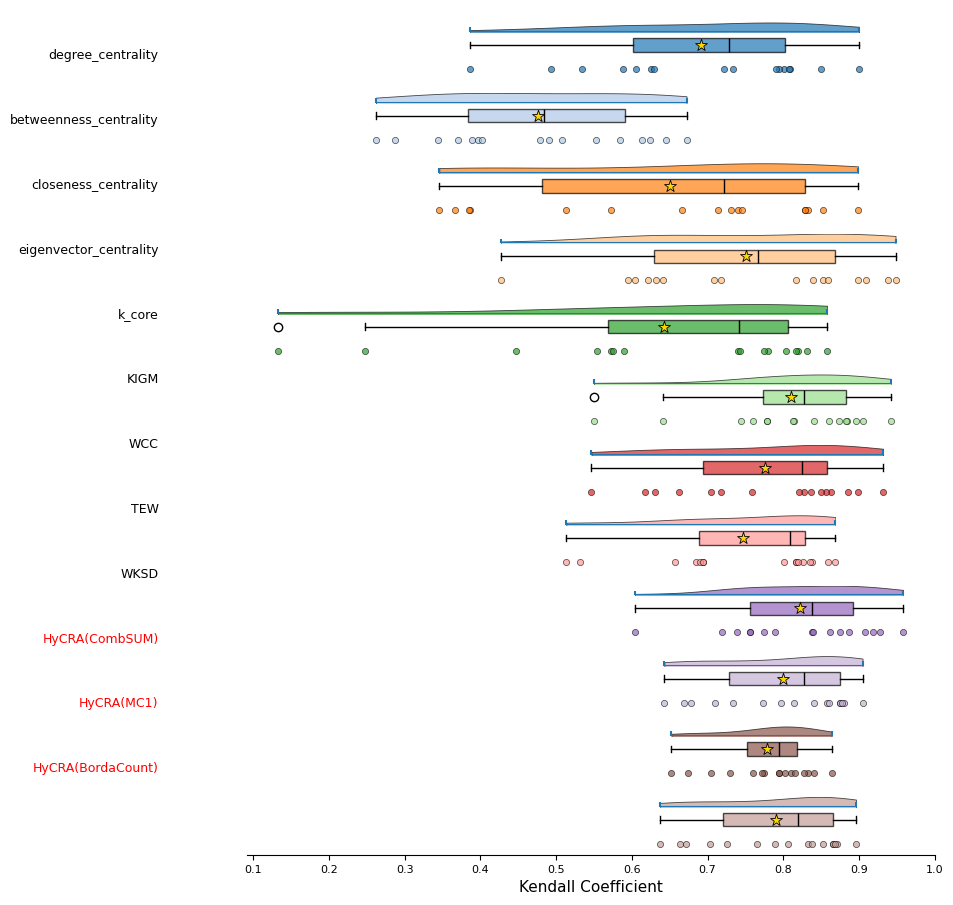

图表已保存为: vertical_methods_compact.png


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns

# ==================== 配置（紧凑但字体美化）====================
FILE_PATH = "kendall_analysis-1.xlsx"
SHEET_NAME = "kendall"
OUTPUT_FILE = "vertical_methods_compact.png"
FIG_WIDTH = 8.0                 # 宽度（英寸）
FIG_HEIGHT_PER_METHOD = 0.8     # 每方法高度（英寸）
X_PADDING = 0.05
# ============================================================

# 读取数据
df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME, index_col=0, header=0)
df_methods = df.iloc[:16, :12].copy()
methods = df_methods.columns.tolist()
n_methods = len(methods)

# 定义我们的方法
our_methods = ['HyCRA(CombSUM)', 'HyCRA(MC1)', 'HyCRA(BordaCount)']

# 计算均值
means = df_methods.mean().values

# 全局x轴范围
all_vals = df_methods.values.flatten()
x_min, x_max = all_vals.min(), all_vals.max()
x_range = x_max - x_min
x_min -= X_PADDING * x_range
x_max += X_PADDING * x_range

# 高对比度颜色
palette = sns.color_palette("tab20", n_methods)
method_colors = dict(zip(methods, palette))

total_height = n_methods * FIG_HEIGHT_PER_METHOD
fig = plt.figure(figsize=(FIG_WIDTH, total_height))

# 主GridSpec
gs_main = fig.add_gridspec(n_methods, 1, hspace=0.0)

def draw_half_violin_upper(ax, data, color):
    parts = ax.violinplot(data, positions=[0], vert=False, widths=0.7,
                          showmeans=False, showmedians=False)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
        pc.set_edgecolor('black')
        pc.set_linewidth(0.6)
        verts = pc.get_paths()[0].vertices
        xmin = verts[:, 0].min()
        xmax = verts[:, 0].max()
        ymax = verts[:, 1].max()
        rect = Rectangle((xmin, 0), xmax - xmin, ymax,
                         transform=ax.transData, clip_on=False)
        pc.set_clip_path(rect)

box_axes = []

for i, method in enumerate(methods):
    data_vals = df_methods[method].values
    mean_val = means[i]
    color = method_colors[method]
    
    gs_inner = gs_main[i].subgridspec(3, 1, hspace=0.08, height_ratios=[1,1,1])
    
    ax_violin = fig.add_subplot(gs_inner[0,0])
    ax_box = fig.add_subplot(gs_inner[1,0], sharex=ax_violin)
    ax_scatter = fig.add_subplot(gs_inner[2,0], sharex=ax_violin)
    
    box_axes.append(ax_box)
    
    # 上半小提琴
    draw_half_violin_upper(ax_violin, data_vals, color)
    ax_violin.set_ylim(0, 0.8)
    ax_violin.tick_params(bottom=False, labelbottom=False, left=False, labelleft=False)
    for spine in ax_violin.spines.values():
        spine.set_visible(False)
    ax_violin.grid(False)
    
    # 箱线图
    bp = ax_box.boxplot(data_vals, positions=[0], vert=False, widths=0.6,
                        patch_artist=True, showmeans=False, meanline=False)
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][0].set_edgecolor('black')
    for w in bp['whiskers']: w.set_color('black')
    for c in bp['caps']: c.set_color('black')
    for m in bp['medians']: m.set_color('black')
    ax_box.scatter(mean_val, 0, marker='*', color='gold', s=80,
                   edgecolor='black', linewidth=0.6, zorder=10)
    ax_box.set_ylim(-0.5, 0.5)
    ax_box.tick_params(bottom=False, labelbottom=False, left=False, labelleft=False)
    for spine in ax_box.spines.values():
        spine.set_visible(False)
    ax_box.grid(False)
    
    # 散点图
    y_pos = np.zeros_like(data_vals)
    ax_scatter.scatter(data_vals, y_pos, color=color, alpha=0.7,
                       s=20, edgecolor='black', linewidth=0.5)
    ax_scatter.set_ylim(-0.5, 0.5)
    ax_scatter.set_xlim(x_min, x_max)
    ax_scatter.tick_params(bottom=True, labelbottom=True if i==n_methods-1 else False,
                           left=False, labelleft=False)
    for spine in ax_scatter.spines.values():
        spine.set_visible(False)
    ax_scatter.grid(False)
    if i == n_methods-1:
        ax_scatter.spines['bottom'].set_visible(True)
        ax_scatter.set_xlabel('Kendall Coefficient', fontsize=11)
        # 新增：设置x轴刻度从0.1到1.0，步长0.1
        ax_scatter.set_xticks(np.arange(0.1, 1.05, 0.1))
        ax_scatter.set_xticklabels([f'{x:.1f}' for x in np.arange(0.1, 1.05, 0.1)], fontsize=8)
    else:
        ax_scatter.spines['bottom'].set_visible(False)
        ax_scatter.tick_params(bottom=False, labelbottom=False)

# 方法名称标注：我们的方法用红色，其他黑色
for method, ax_box in zip(methods, box_axes):
    bbox = ax_box.get_position()
    #print(bbox.y0 , bbox.y1 )
    y_center = (bbox.y0 + bbox.y1) / 1.90
    text_color = 'red' if method in our_methods else 'black'
    fig.text(0.01, y_center, method, ha='right', va='center',
             fontsize=9, color=text_color)



# 整体标题
#fig.suptitle('Comparison of Centrality Methods across Networks', y=0.98,
#             fontsize=16, fontweight='bold')

plt.subplots_adjust(left=0.12, right=0.98, top=0.94, bottom=0.06)
plt.savefig(OUTPUT_FILE, dpi=600, bbox_inches='tight')
plt.show()
print(f"图表已保存为: {OUTPUT_FILE}")

# 4、不同网络不同方法下的单调性对比表

In [7]:
import pandas as pd
import numpy as np # 确保导入 numpy

# 读取数据 (您的原始代码)
kendall_df = pd.read_excel("monotonicity_analysis-1.xlsx").iloc[:,:-1]

# 获取数值列（假设第一列为网络名称）
value_cols = kendall_df.columns[1:]

# 识别最后一行的网络名称（判断是否为 "Std."）- 优化，只计算一次
last_row_is_std = (kendall_df.iloc[-1, 0] == "Std.")

def highlight_best(row):
    # 初始化样式列表
    styles = [''] * len(row)
    
    # 浮点数比较的容差值
    tolerance = 1e-9 # 可以根据数据精度调整，例如1e-6, 1e-9等

    # 判断是否为 Std. 行
    if row.name == kendall_df.index[-1] and last_row_is_std:
        # Std. 行，高亮最小值
        target_val = row[value_cols].min()
        # 使用 np.isclose 进行浮点数近似比较
        for col_name in value_cols:
            if np.isclose(row[col_name], target_val, atol=tolerance):
                idx = row.index.get_loc(col_name)
                styles[idx] = 'color: red; font-weight: bold'
    else:
        # 其他行，高亮最大值
        target_val = row[value_cols].max()
        # 使用 np.isclose 进行浮点数近似比较
        for col_name in value_cols:
            if np.isclose(row[col_name], target_val, atol=tolerance):
                idx = row.index.get_loc(col_name)
                styles[idx] = 'color: red; font-weight: bold'
    
    return styles

# 应用样式 (您的原始代码)
styled_df = kendall_df.style.apply(highlight_best, axis=1)
styled_df

,Network,degree_centrality,betweenness_centrality,closeness_centrality,eigenvector_centrality,k_core,KIGM,WCC,TEW,WKSD,HyCRA(CombSUM),HyCRA(MC1),HyCRA(BordaCount)
0,Dolphine,0.831173,0.962287,0.973734,0.997886,0.376948,0.981664,0.997886,0.994721,0.982396,0.993664,0.997886,0.992610
1,Jazz,0.965941,0.988548,0.987834,0.999282,0.794414,0.999159,0.999282,0.998975,0.999231,0.997745,0.999282,0.997336
2,Disease,0.770688,0.273261,0.994739,0.995970,0.695034,0.986217,0.995745,0.995557,0.923388,0.994679,0.996045,0.993943
3,Email,0.887367,0.940009,0.998803,0.999897,0.808813,0.997693,0.999897,0.999819,0.998015,0.999679,0.999897,0.999548
4,Netscience,0.764206,0.338736,0.992754,0.995036,0.642083,0.984544,0.995036,0.994454,0.986490,0.994702,0.995176,0.994424
5,Wikivote,0.804103,0.876935,0.998764,0.999711,0.726517,0.994761,0.999711,0.999635,0.994720,0.999316,0.999726,0.999159
6,Yeast,0.488431,0.506258,0.995681,0.996037,0.297151,0.945380,0.996038,0.995972,0.953099,0.995695,0.996040,0.995582
7,Power,0.592651,0.831345,0.999829,0.999889,0.245995,0.940606,0.999884,0.999881,0.940021,0.999805,0.999891,0.999776
8,911,0.812000,0.748486,0.965402,0.989452,0.641016,0.980150,0.989452,0.985776,0.983702,0.987349,0.989452,0.986298
9,CA-CSphd,0.243204,0.266265,0.977806,0.978734,0.012754,0.846069,0.978656,nan,0.869245,0.978552,0.978748,0.978415


# 5. 绘制柱形组图对不同网络下不同方法 单调性 结果进行值大小的比较

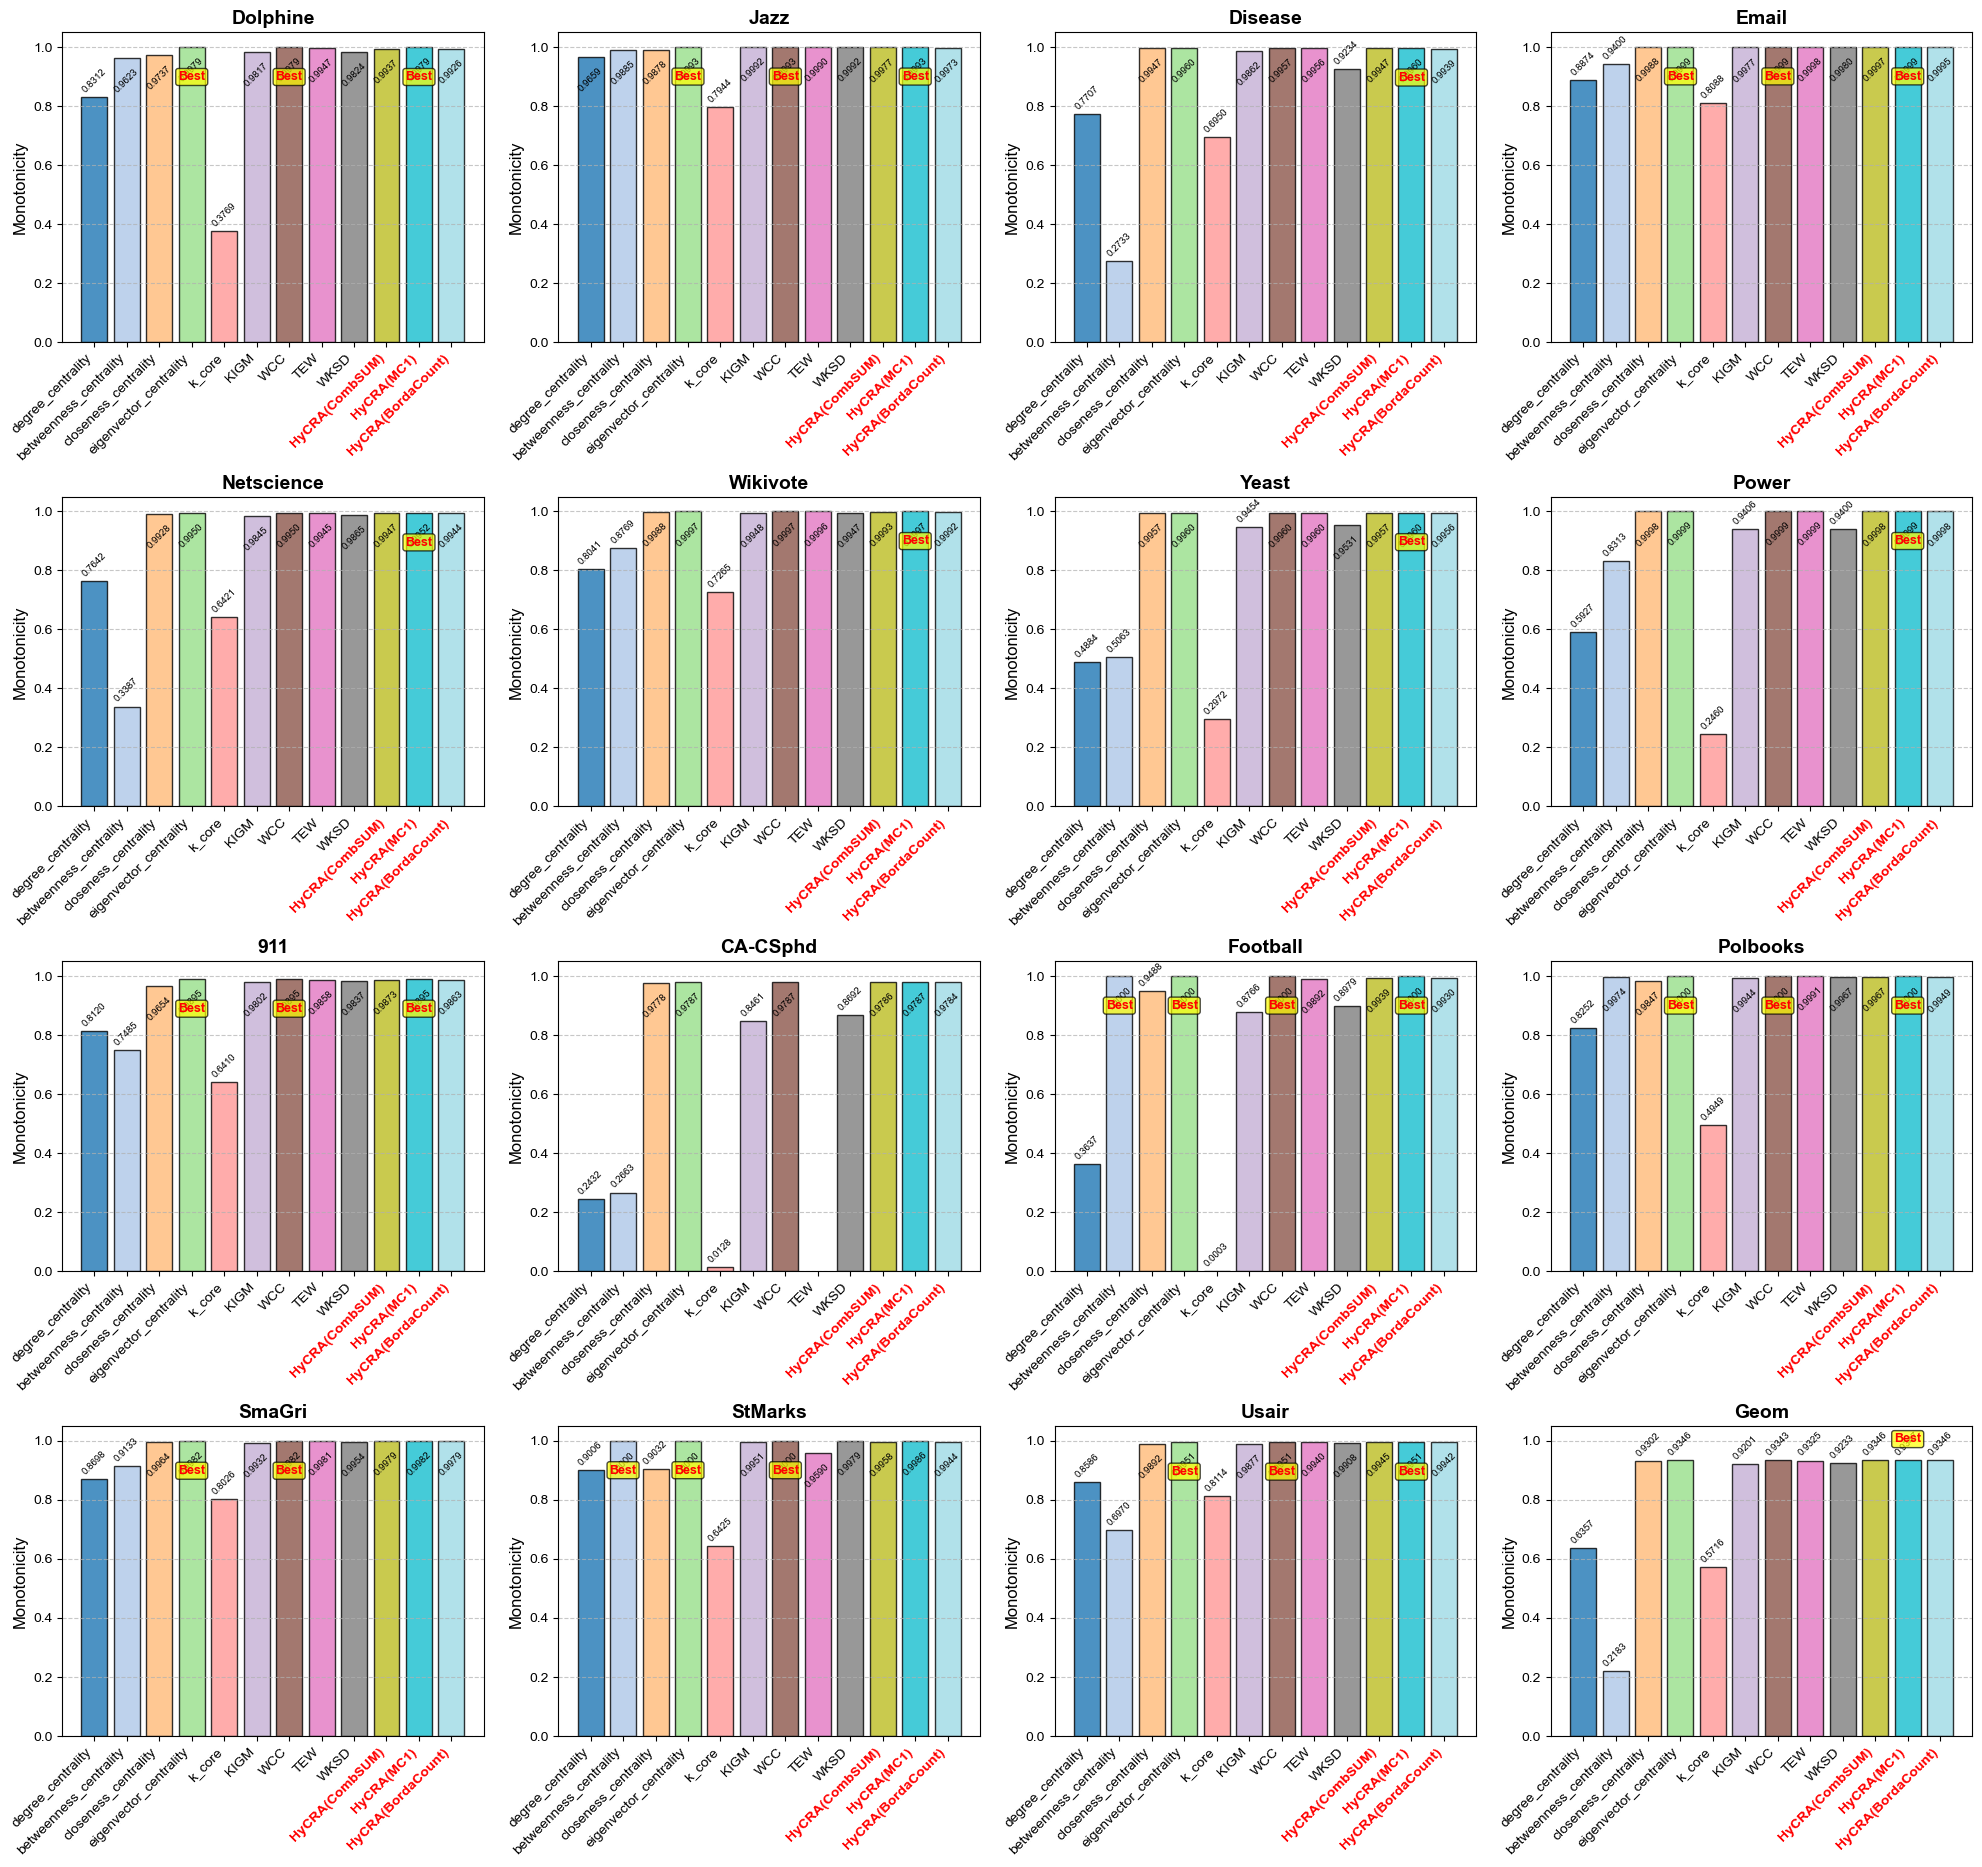

图表已保存为: Monotonicity_Comparison_Across_Networks.png


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取数据
file_path = "monotonicity_analysis-1.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

# 过滤出网络行（排除 "Mean" 和 "Std." 行）
df_networks = df[~df["Network"].isin(["Mean", "Std."])].copy()

# 确定方法列
all_cols = df_networks.columns.tolist()
method_cols = [col for col in all_cols if col != "Network" and "Unnamed" not in str(col)]

# 需要高亮显示的方法（红色加粗标签）—— 使用完整的列名
highlight_methods = ['HyCRA(CombSUM)', 'HyCRA(MC1)', 'HyCRA(BordaCount)']

# 使用高对比色
colors = plt.cm.tab20(np.linspace(0, 1, len(method_cols)))

# 创建子图
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()

for ax, (idx, row) in zip(axes, df_networks.iterrows()):
    network = row["Network"]
    values = row[method_cols].values.astype(float)

    # 找出所有最大值索引（考虑浮点精度）
    max_val = np.max(values)
    tol = 1e-9
    max_indices = np.where(np.isclose(values, max_val, rtol=1e-9, atol=tol))[0]

    # 绘制柱状图
    bars = ax.bar(method_cols, values, color=colors, edgecolor='black', alpha=0.8)

    ax.set_title(f"{network}", fontsize=14, fontweight='bold')
    ax.set_ylabel("Monotonicity", fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # x轴标签：高亮方法红色加粗
    ax.set_xticks(range(len(method_cols)))
    ax.set_xticklabels(method_cols, rotation=45, ha='right', fontsize=10)
    for tick_label in ax.get_xticklabels():
        if tick_label.get_text() in highlight_methods:
            tick_label.set_color('red')
            tick_label.set_fontweight('bold')

    # 优化柱顶数值标注：旋转45度，根据柱高动态调整垂直位置
    for bar, val in zip(bars, values):
        x_center = bar.get_x() + bar.get_width() / 2
        y_pos = bar.get_height()
        if y_pos > 0.95:
            y_text = y_pos - 0.03
            va = 'top'
        else:
            y_text = y_pos + 0.01
            va = 'bottom'
        ax.text(x_center, y_text, f"{val:.4f}",
                ha='center', va=va, fontsize=7, rotation=45)

    # 标注所有最优柱子（包括并列）
    for i in max_indices:
        bar = bars[i]
        x_center = bar.get_x() + bar.get_width() / 2
        y_base = bar.get_height()
        if y_base > 0.95:
            y_text = y_base - 0.08
            va = 'top'
        else:
            y_text = y_base + 0.05
            va = 'bottom'
        ax.text(x_center, y_text, "Best",
                ha='center', va=va, fontsize=9, fontweight='bold',
                color='red', bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.7))

# 调整布局
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.subplots_adjust(top=0.92)
plt.savefig("Monotonicity_Comparison_Across_Networks.png", dpi=600, bbox_inches='tight')
plt.show()
print("图表已保存为: Monotonicity_Comparison_Across_Networks.png")

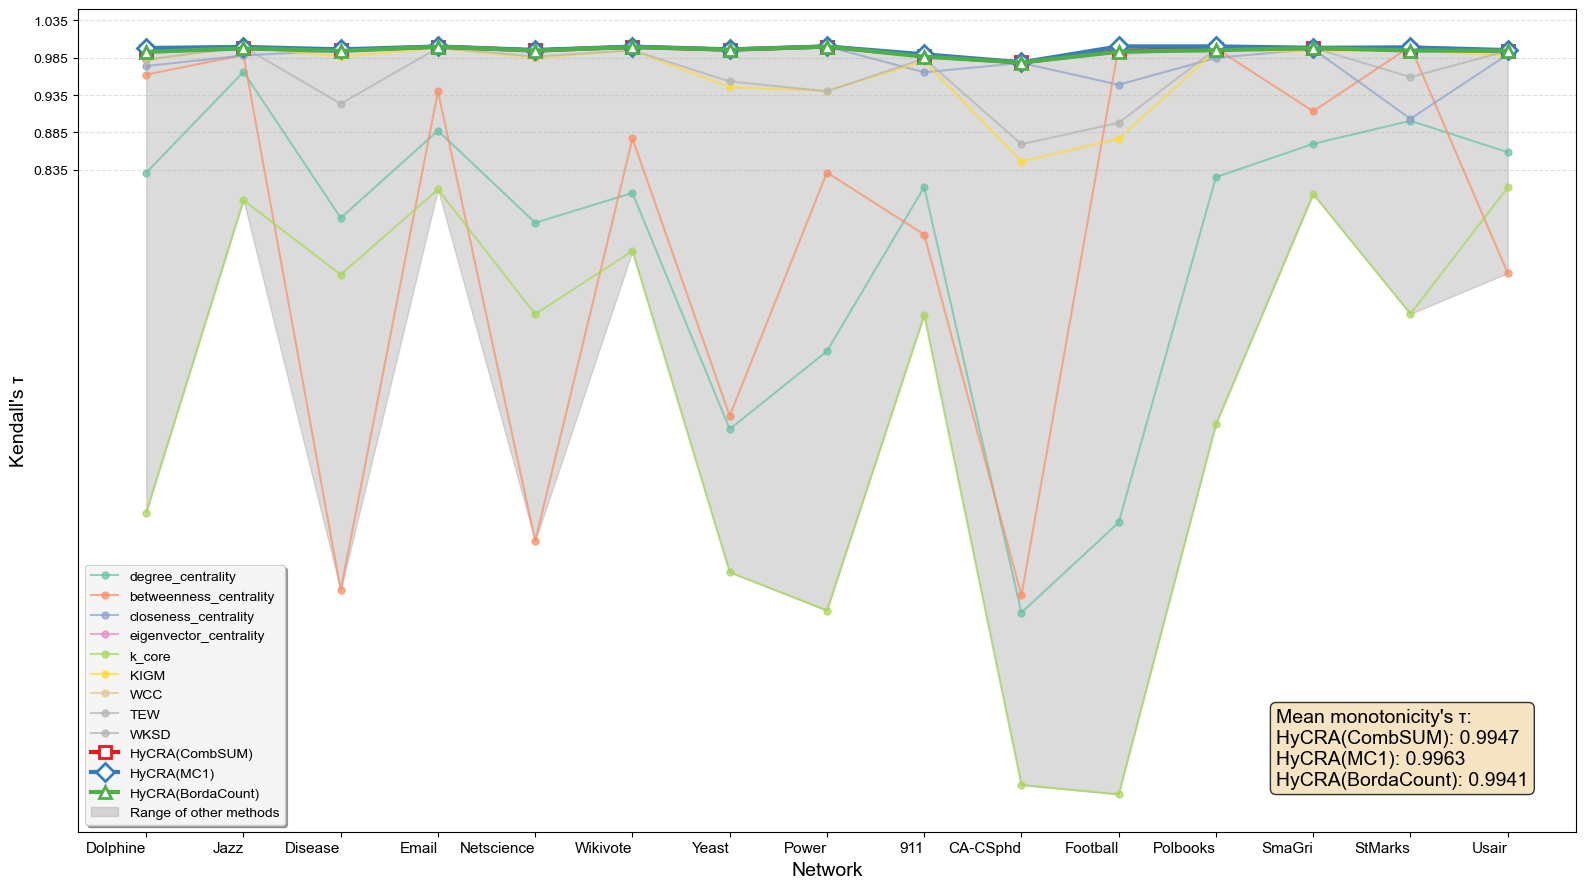

图表已保存为: monotonicity_highlight.png


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 设置字体（英文不需要中文字体，但若系统有英文默认即可）
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据
df = pd.read_excel('monotonicity_analysis-1.xlsx', sheet_name='Sheet1')

# 提取网络和方法
networks = df['Network'].iloc[:-3].tolist()
all_methods = ['degree_centrality', 'betweenness_centrality', 'closeness_centrality', 
               'eigenvector_centrality', 'k_core', 'KIGM', 'WCC', 
               'TEW', 'WKSD', 'HyCRA(CombSUM)', 'HyCRA(MC1)', 'HyCRA(BordaCount)']

# 高亮的方法
highlight_methods = ['HyCRA(CombSUM)', 'HyCRA(MC1)', 'HyCRA(BordaCount)']
other_methods = [m for m in all_methods if m not in highlight_methods]

# 提取数据
data_all = df[all_methods].iloc[:-3].values

# 高亮方法的颜色和标记形状
highlight_colors = {
    'HyCRA(CombSUM)': '#e41a1c',      # red
    'HyCRA(MC1)': '#377eb8',          # blue
    'HyCRA(BordaCount)': '#4daf4a'    # green
}
highlight_markers = {
    'HyCRA(CombSUM)': 's',      # square
    'HyCRA(MC1)': 'D',          # diamond
    'HyCRA(BordaCount)': '^'    # triangle up
}

# 其他方法使用 Set2 调色板（美观且区分度高）
other_colors = plt.cm.Set2(np.linspace(0, 1, len(other_methods)))

# 线条样式
highlight_linewidth = 3
other_linewidth = 1.5

# 创建图形
fig, ax = plt.subplots(figsize=(16, 9), dpi=100)

# 1. 绘制其他方法（使用不同颜色）
for i, method in enumerate(other_methods):
    ax.plot(networks, data_all[:, all_methods.index(method)], 
            color=other_colors[i], linewidth=other_linewidth, 
            marker='o', markersize=5, alpha=0.7, label=method)

# 2. 绘制高亮方法（使用不同形状）
for method in highlight_methods:
    idx = all_methods.index(method)
    ax.plot(networks, data_all[:, idx], 
            color=highlight_colors[method], linewidth=highlight_linewidth,
            marker=highlight_markers[method], markersize=9, markerfacecolor='white', 
            markeredgewidth=2, markeredgecolor=highlight_colors[method],
            label=method, zorder=10)

# 3. 计算并绘制其他方法的取值范围阴影（使用 nanmin/nanmax 避免 NaN 断裂）
other_values = np.array([data_all[:, all_methods.index(m)] for m in other_methods])
min_other = np.nanmin(other_values, axis=0)   # 忽略 NaN
max_other = np.nanmax(other_values, axis=0)   # 忽略 NaN
ax.fill_between(range(len(networks)), min_other, max_other, 
                color='#999999', alpha=0.35, label='Range of other methods')

# 设置图表（英文标签）
ax.set_xlabel('Network', fontsize=14)
ax.set_ylabel("Kendall's τ", fontsize=14)
ax.set_xticks(range(len(networks)))
ax.set_xticklabels(networks, ha='right', fontsize=11)
ax.set_yticks(np.arange(0.835, 1.05, 0.05))
ax.grid(True, linestyle='--', alpha=0.4, axis='y')

# 图例（放在左下角）
legend = ax.legend(loc='lower left', fontsize=10, frameon=True, fancybox=True, shadow=True)
legend.get_frame().set_alpha(0.9)

# 添加平均单调性文本标注
mean_comb = np.mean(data_all[:, all_methods.index('HyCRA(CombSUM)')])
mean_mc1 = np.mean(data_all[:, all_methods.index('HyCRA(MC1)')])
mean_borda = np.mean(data_all[:, all_methods.index('HyCRA(BordaCount)')])
ax.text(0.80, 0.15, f'Mean monotonicity\'s τ:\nHyCRA(CombSUM): {mean_comb:.4f}\nHyCRA(MC1): {mean_mc1:.4f}\nHyCRA(BordaCount): {mean_borda:.4f}',
        transform=ax.transAxes, fontsize=14, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('monotonicity_highlight.png', dpi=600, bbox_inches='tight')
plt.show()
print("图表已保存为: monotonicity_highlight.png")

# 6. KIGM、WCC、TEW、WKSD 对参数敏感性分析

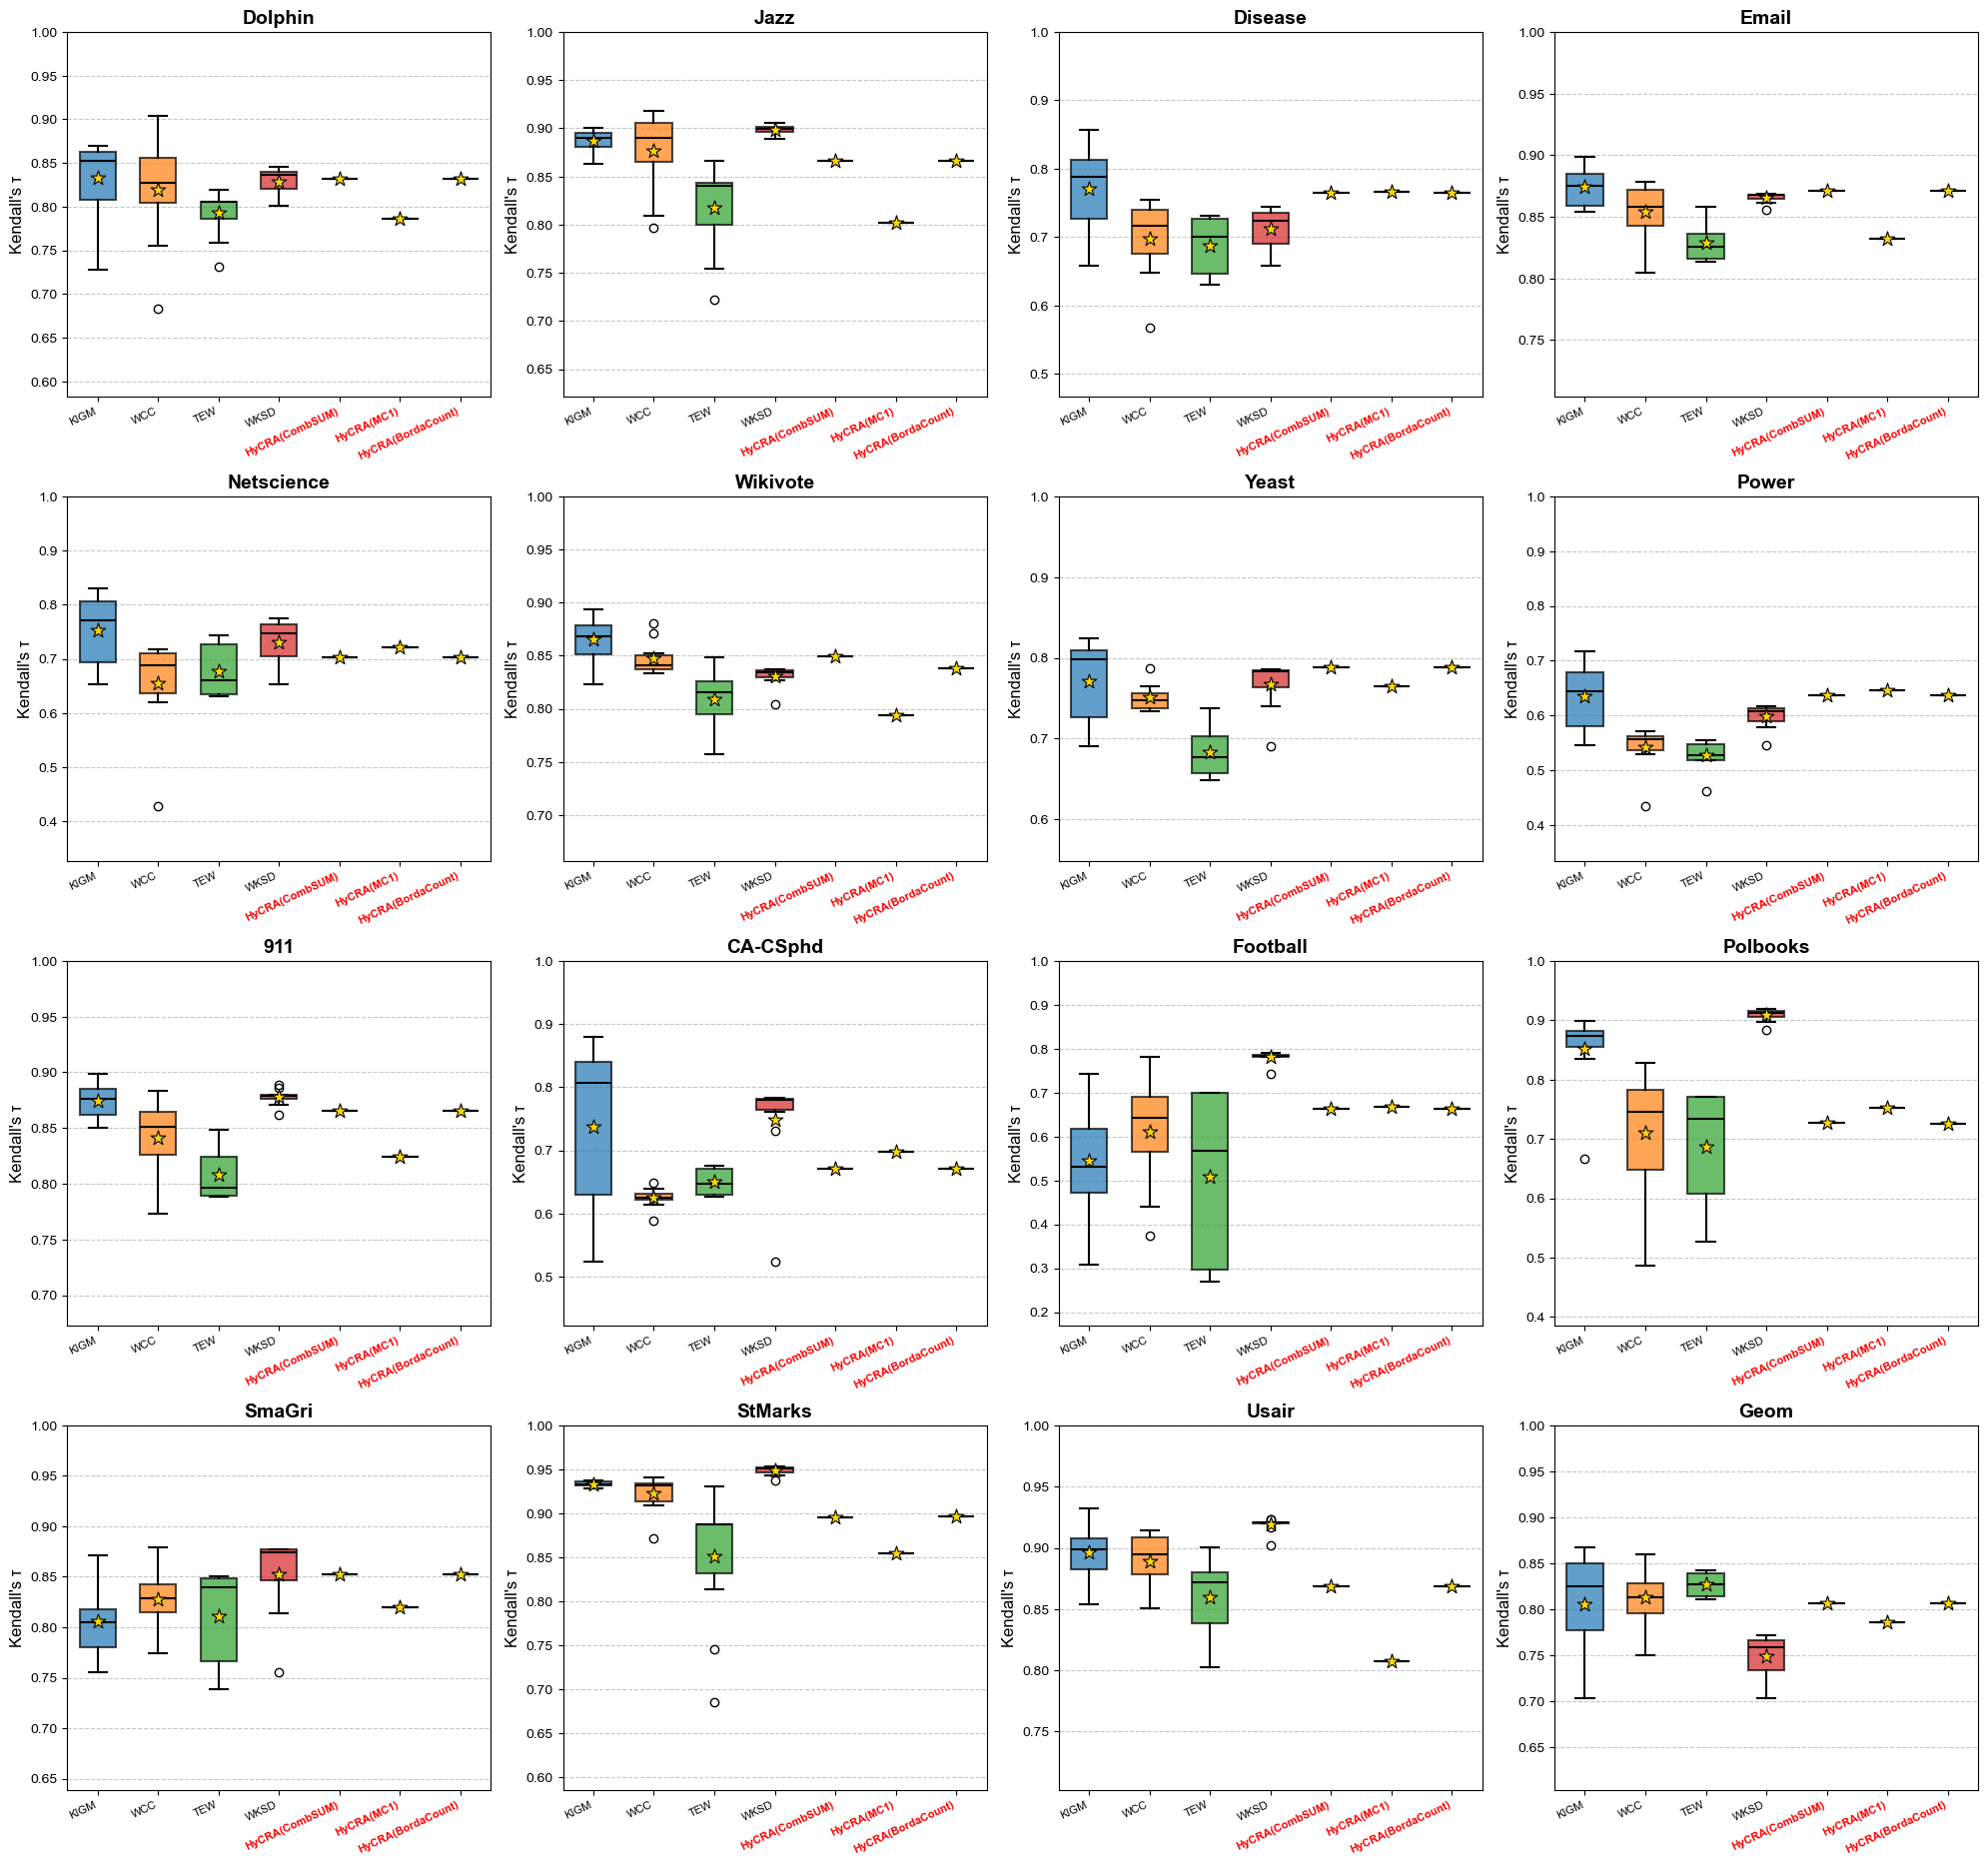

图表已保存为: Sensitivity_Analysis_of_Four_Methods_Across_Networks.png


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 定义网络名称和对应的文件路径
networks = {
    "Dolphin": "Dolphin - advanced_kendall_correlation_results - 参数敏感性.csv",
    "Jazz": "Jazz - advanced_kendall_correlation_results - 参数敏感性.csv",
    "Disease": "Disease - advanced_kendall_correlation_results - 参数敏感性.csv",
    "Email": "Email - advanced_kendall_correlation_results - 参数敏感性.csv",
    "Netscience": "Netscience - advanced_kendall_correlation_results - 参数敏感性.csv",
    "Wikivote": "Wikivote - advanced_kendall_correlation_results - 参数敏感性.csv",
    "Yeast": "Yeast - advanced_kendall_correlation_results - 参数敏感性.csv",
    "Power": "Power - advanced_kendall_correlation_results - 参数敏感性.csv",
    "911": "911 - advanced_kendall_correlation_results - 参数敏感性.csv",
    "CA-CSphd": "CA-CSphd - advanced_kendall_correlation_results - 参数敏感性.csv",
    "Football": "Football - advanced_kendall_correlation_results - 参数敏感性.csv",
    "Polbooks": "Polbooks - advanced_kendall_correlation_results - 参数敏感性.csv",
    "SmaGri": "SmaGri - advanced_kendall_correlation_results - 参数敏感性.csv",
    "StMarks": "StMarks - advanced_kendall_correlation_results - 参数敏感性.csv",
    "Usair": "Usair - advanced_kendall_correlation_results - 参数敏感性.csv",
    "Geom": "Geom - advanced_kendall_correlation_results - 参数敏感性.csv"
}

# 要提取的方法名称
methods = ["KIGM", "WCC", "TEW", "WKSD","HyCRA(CombSUM)","HyCRA(MC1)","HyCRA(BordaCount)"]


# 存储每个网络的数据
data_by_network = {}

for network, file in networks.items():
    df = pd.read_csv(file, index_col=0, encoding='utf-8')
    method_values = {}
    for method in methods:
        if method in df.index:
            vals = pd.to_numeric(df.loc[method], errors='coerce').dropna().values
            method_values[method] = vals
        else:
            method_values[method] = []
    data_by_network[network] = method_values

#colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()

for ax, (network, method_vals) in zip(axes, data_by_network.items()):
    data_to_plot = [method_vals[m] for m in methods]
    all_values = np.concatenate(data_to_plot)
    ylim_min = np.min(all_values)
    
    bp = ax.boxplot(data_to_plot, positions=range(1, len(methods)+1),
                    widths=0.6, patch_artist=True,
                    boxprops=dict(linewidth=1.5),
                    medianprops=dict(color='black', linewidth=1.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # 五角星标注均值
    for i, vals in enumerate(data_to_plot):
        x_pos = i + 1
        mean_val = np.mean(vals)
        ax.scatter(x_pos, mean_val, marker='*', color='gold', s=120,
                   edgecolor='black', linewidth=0.8, zorder=10)
    
    ax.set_title(f"{network}", fontsize=14, fontweight='bold')
    ax.set_ylabel("Kendall's τ", fontsize=12)
    ax.set_xticks(range(1, len(methods)+1))
    ax.set_xticklabels(methods, fontsize=8, rotation=25, ha='right')
    
    # ========== 高亮三个方法 ==========
    for tick_label in ax.get_xticklabels():
        if tick_label.get_text() in ["HyCRA(CombSUM)", "HyCRA(MC1)", "HyCRA(BordaCount)"]:
            tick_label.set_color('red')
            tick_label.set_fontweight('bold')
    # =================================
    
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_ylim(ylim_min - 0.1, 1)

# 可选：添加图例（箱线图颜色+五角星）
box_handles = [plt.Rectangle((0,0),1,1, color=colors[i]) for i in range(len(methods))]
star_handle = plt.Line2D([0], [0], marker='*', color='gold', markersize=10,
                         linestyle='None', markeredgecolor='black', label='Mean')
handles = box_handles + [star_handle]
labels = methods + ['Mean']
#fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02),
#           ncol=len(methods)+1, fontsize=11, frameon=False)

#fig.suptitle("Sensitivity Analysis of Four Methods Across Networks", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.subplots_adjust(top=0.92)
plt.savefig('Sensitivity_Analysis_of_Four_Methods_Across_Networks.png', dpi=600, bbox_inches='tight')
plt.show()
print("图表已保存为: Sensitivity_Analysis_of_Four_Methods_Across_Networks.png")

# 7.  HyCRA 对传播概率β不敏感

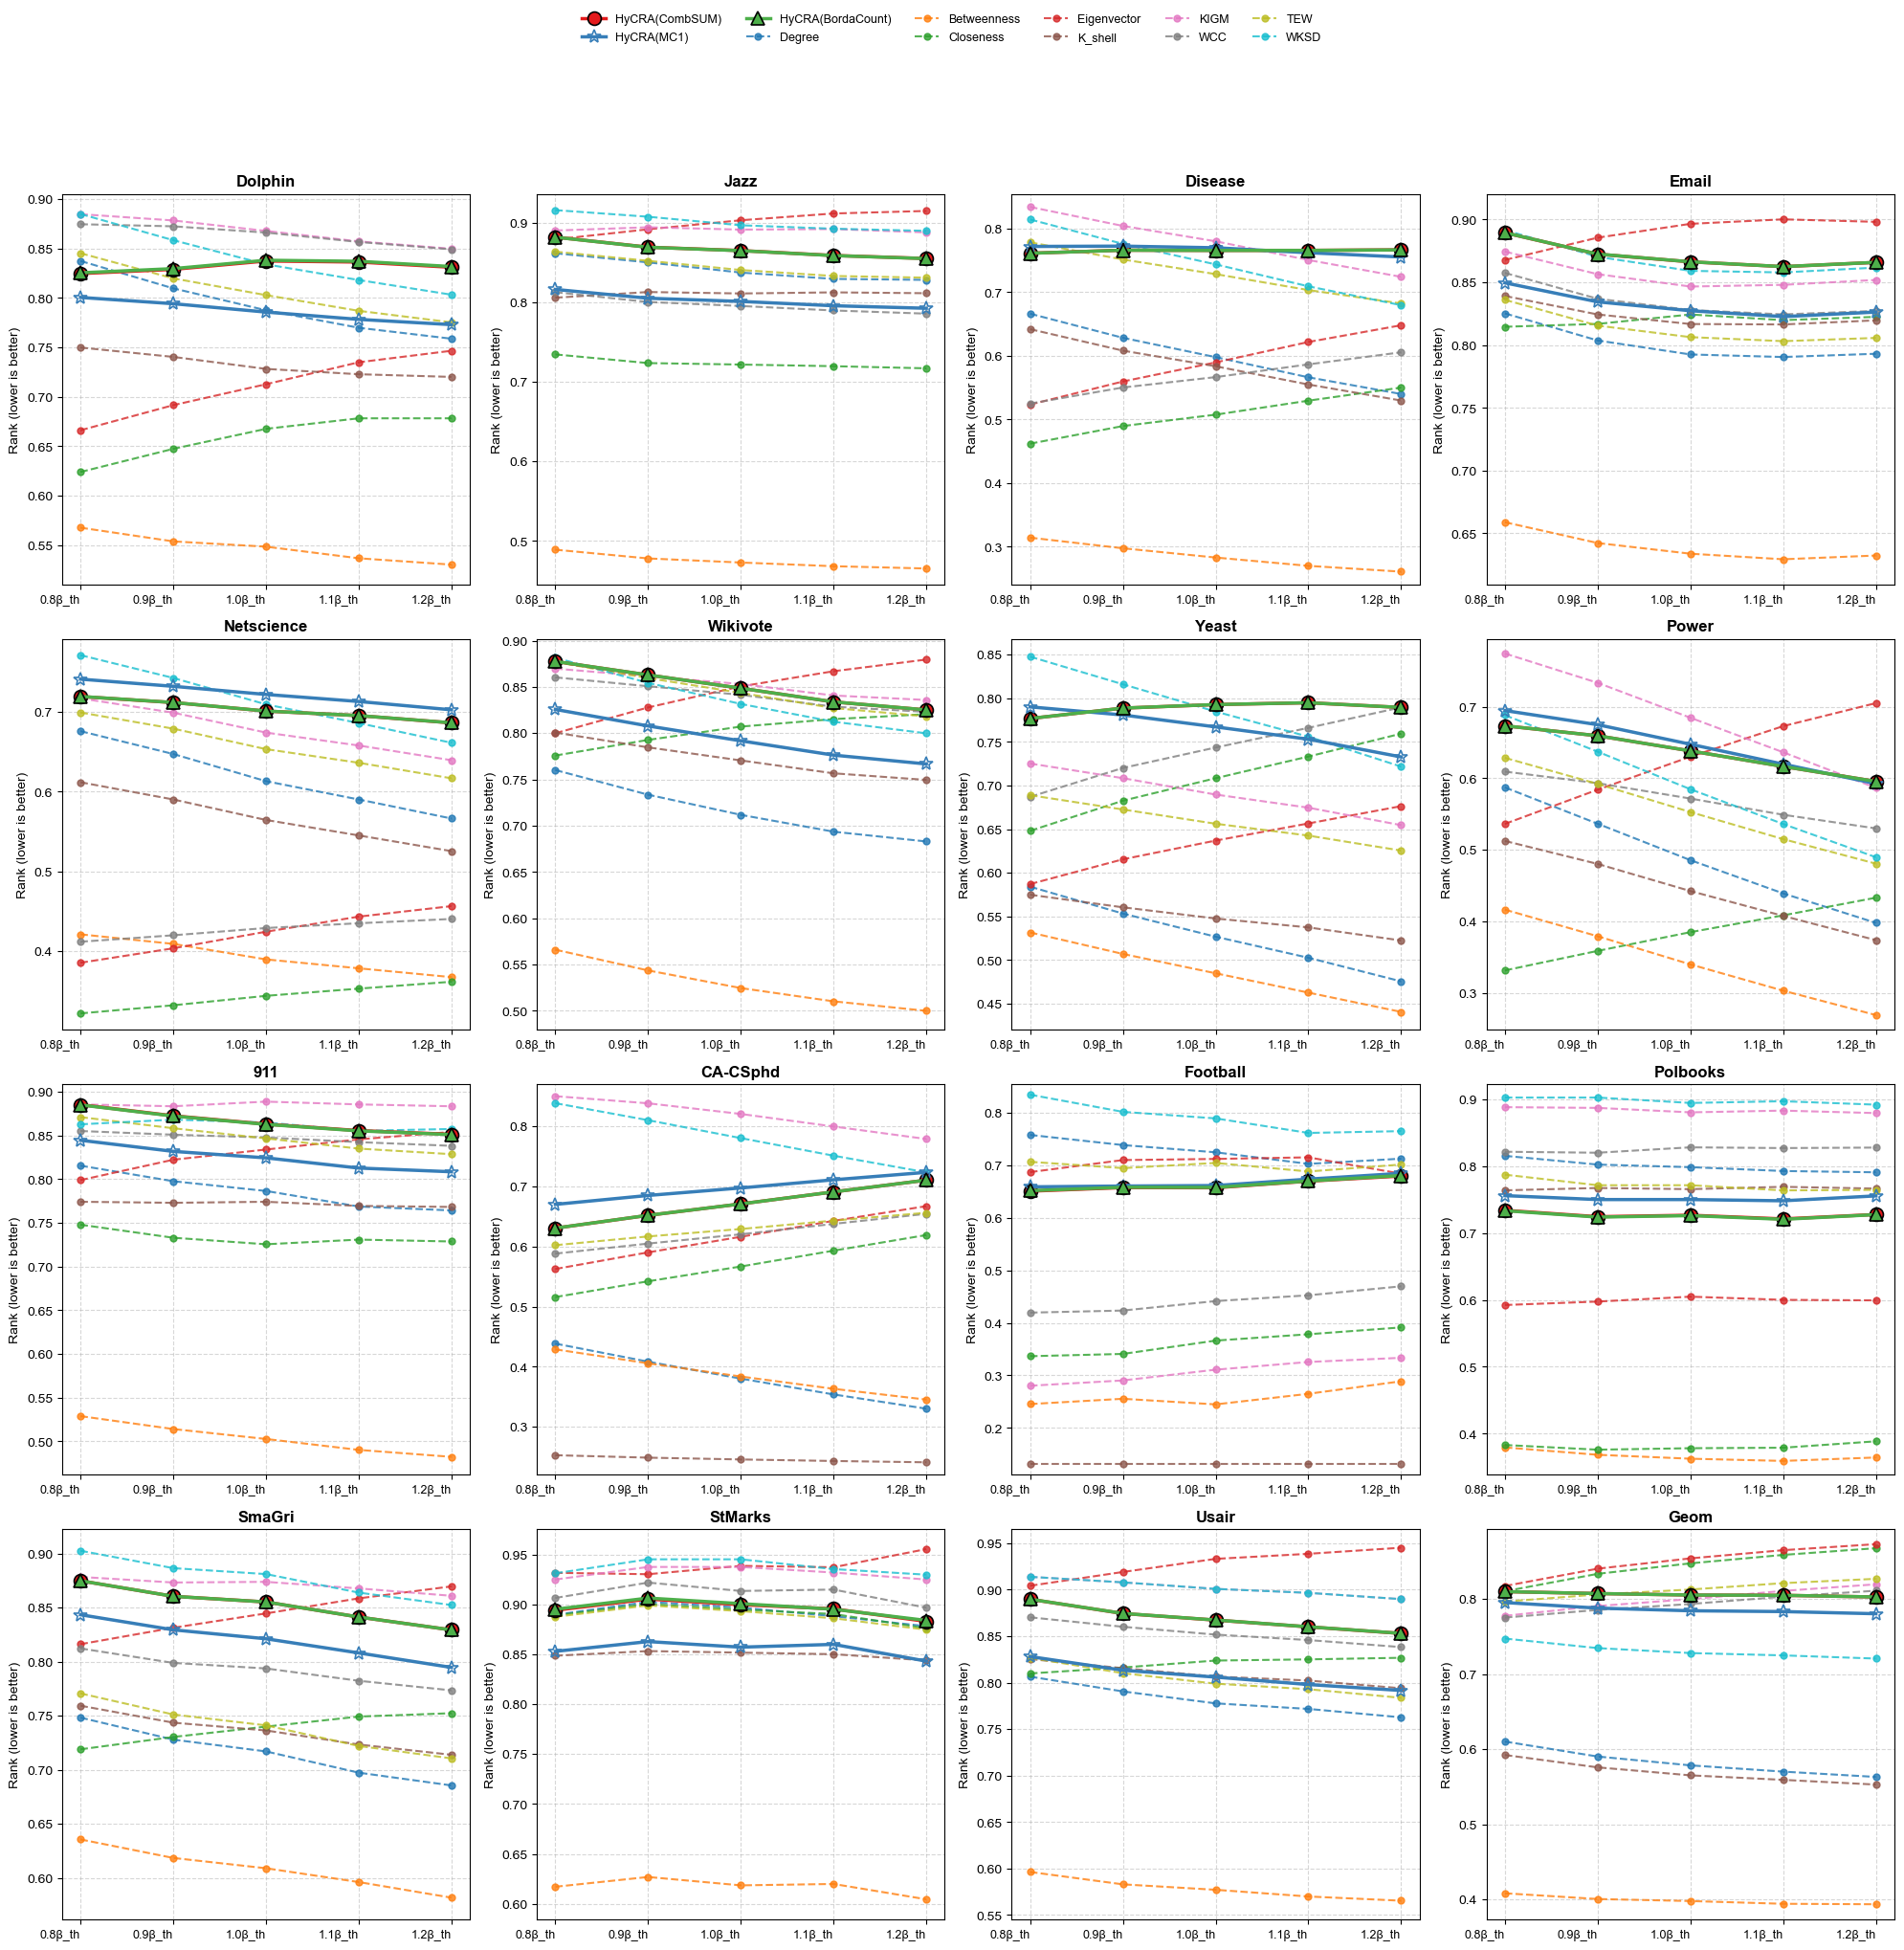

图表已保存为: HyCRA_vs_others_beta_sensitivity.png


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import random

# 固定随机种子
random.seed(42)

# 网络文件映射
networks = {
    "Dolphin": "Dolphin - advanced_kendall_correlation_results.csv",
    "Jazz": "Jazz - advanced_kendall_correlation_results.csv",
    "Disease": "Disease - advanced_kendall_correlation_results.csv",
    "Email": "Email - advanced_kendall_correlation_results.csv",
    "Netscience": "Netscience - advanced_kendall_correlation_results.csv",
    "Wikivote": "Wikivote - advanced_kendall_correlation_results.csv",
    "Yeast": "Yeast - advanced_kendall_correlation_results.csv",
    "Power": "Power - advanced_kendall_correlation_results.csv",
    "911": "911 - advanced_kendall_correlation_results.csv",
    "CA-CSphd": "CA-CSphd - advanced_kendall_correlation_results.csv",
    "Football": "Football - advanced_kendall_correlation_results.csv",
    "Polbooks": "Polbooks - advanced_kendall_correlation_results.csv",
    "SmaGri": "SmaGri - advanced_kendall_correlation_results.csv",
    "StMarks": "StMarks - advanced_kendall_correlation_results.csv",
    "Usair": "Usair - advanced_kendall_correlation_results.csv",
    "Geom": "Geom - advanced_kendall_correlation_results.csv"
}

# HyCRA 方法（高亮）
hycra_methods = {
    "CombSUM_Rank": "HyCRA(CombSUM)",
    "MC1_Rank": "HyCRA(MC1)",
    "BordaCount_Rank": "HyCRA(BordaCount)"
}
hycra_colors = ["#e41a1c", "#377eb8", "#4daf4a"]
hycra_markers = ["o", "*", "^"]
hycra_linestyles = ["-", "-", "-"]
hycra_linewidth = 2.5
hycra_markersize = 10
marker_fill = [True, False, True]  # 实心、空心、实心

# 其他方法（9种）
other_base_names = [
    "degree_centrality",
    "betweenness_centrality",
    "closeness_centrality",
    "eigenvector_centrality",
    "k_core",
    "KIGM",
    "WCC",
    "TEW",
    "WKSD"
]

				

# 显示名称（美化）
other_display = {
    "degree_centrality": "Degree",
    "betweenness_centrality": "Betweenness",
    "closeness_centrality": "Closeness",
    "eigenvector_centrality": "Eigenvector",
    "k_core": "K_shell",
    "KIGM": "KIGM",
    "WCC": "WCC",
    "TEW": "TEW",
    "WKSD": "WKSD"
}
# 使用 tab10 调色板（9种颜色）
other_colors = plt.cm.tab10(np.linspace(0, 1, 9))
other_linestyle = "--"
other_linewidth = 1.5
other_markersize = 5
other_alpha = 0.8

beta_labels = ["0.8β_th", "0.9β_th", "1.0β_th", "1.1β_th", "1.2β_th"]

# 存储每个网络的数据
data_by_network = {}

for network, file in networks.items():
    if not os.path.exists(file):
        print(f"警告: 文件 {file} 不存在，跳过 {network}")
        continue
    df = pd.read_csv(file, index_col=0, encoding='utf-8')
    all_index = df.index.tolist()
    method_data = {}
    
    # 提取 HyCRA 方法
    for row_name, display in hycra_methods.items():
        if row_name in df.index:
            vals = df.loc[row_name].iloc[:5].values
            vals = pd.to_numeric(vals, errors='coerce')
            method_data[display] = vals
        else:
            method_data[display] = [np.nan]*5
    
    # 提取其他方法
    for base in other_base_names:
        if base in ["degree_centrality", "betweenness_centrality", "closeness_centrality",
                    "eigenvector_centrality", "k_core"]:
            target = base + "_Rank"
            if target in df.index:
                vals = df.loc[target].iloc[:5].values
                vals = pd.to_numeric(vals, errors='coerce')
                method_data[other_display[base]] = vals
            else:
                method_data[other_display[base]] = [np.nan]*5
        else:
            candidates = [idx for idx in all_index if idx.startswith(base + "_")]
            if candidates:
                chosen = random.choice(candidates)
                vals = df.loc[chosen].iloc[:5].values
                vals = pd.to_numeric(vals, errors='coerce')
                method_data[other_display[base]] = vals
            else:
                method_data[other_display[base]] = [np.nan]*5
    data_by_network[network] = method_data

# 创建子图布局 (4x4)
n_networks = len(data_by_network)
n_cols = 4
n_rows = (n_networks + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes]

for ax, (network, method_data) in zip(axes, data_by_network.items()):
    # 收集所有有效值用于确定 y 轴范围
    all_vals = []
    for vals in method_data.values():
        all_vals.extend(vals[~np.isnan(vals)])
    if all_vals:
        y_min = min(all_vals)
        y_max = max(all_vals)
        y_lower = max(0, y_min - 0.02)
        y_upper = y_max + 0.02
    else:
        y_lower, y_upper = 0, 12

    # 绘制其他方法（彩色虚线，小圆点）- 使用独立计数器
    other_idx = 0
    for display, vals in method_data.items():
        if display in hycra_methods.values():
            continue
        if np.all(np.isnan(vals)):
            other_idx += 1
            continue
        x_vals = np.arange(len(beta_labels))
        valid_mask = ~np.isnan(vals)
        if np.sum(valid_mask) == 0:
            other_idx += 1
            continue
        ax.plot(x_vals[valid_mask], vals[valid_mask],
                color=other_colors[other_idx], linestyle=other_linestyle,
                linewidth=other_linewidth, marker='o', markersize=other_markersize,
                alpha=other_alpha, label=display)
        other_idx += 1

    # 绘制 HyCRA 方法（高亮实线大标记）
    for i, display in enumerate(hycra_methods.values()):
        vals = method_data.get(display)
        if vals is None or np.all(np.isnan(vals)):
            continue
        x_vals = np.arange(len(beta_labels))
        valid_mask = ~np.isnan(vals)
        if np.sum(valid_mask) == 0:
            continue
        facecolor = hycra_colors[i] if marker_fill[i] else 'none'
        edgecolor = 'black' if marker_fill[i] else hycra_colors[i]
        ax.plot(x_vals[valid_mask], vals[valid_mask],
                color=hycra_colors[i], marker=hycra_markers[i], markersize=hycra_markersize,
                linewidth=hycra_linewidth, linestyle=hycra_linestyles[i],
                label=display,
                markerfacecolor=facecolor, markeredgecolor=edgecolor,
                markeredgewidth=1.2)

    ax.set_title(network, fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(beta_labels)))
    ax.set_xticklabels(beta_labels, fontsize=9,  ha='right')
    ax.set_ylabel("Rank (lower is better)", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylim(y_lower, y_upper)

# 隐藏多余的子图
for i in range(n_networks, len(axes)):
    axes[i].axis('off')

# 收集所有图例（按顺序：HyCRA 在前，其他在后）
handles, labels = axes[0].get_legend_handles_labels()
hycra_labels = list(hycra_methods.values())
hycra_handles = [h for h, l in zip(handles, labels) if l in hycra_labels]
other_handles = [h for h, l in zip(handles, labels) if l not in hycra_labels]
other_labels = [l for l in labels if l not in hycra_labels]
handles_sorted = hycra_handles + other_handles
labels_sorted = hycra_labels + other_labels

# 图例放在图上方，分为两行（ncol=6）
fig.legend(handles_sorted, labels_sorted, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=6, fontsize=9, frameon=False)

# 总标题
#fig.suptitle("Sensitivity to Propagation Probability β: HyCRA vs Other Centrality Methods",
#             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.subplots_adjust(top=0.92)
plt.savefig("HyCRA_vs_others_beta_sensitivity.png", dpi=300, bbox_inches='tight')
plt.show()
print("图表已保存为: HyCRA_vs_others_beta_sensitivity.png")